# Workshop figures (CCAI) — the ensemble epistemic signal is confidently wrong under shift

Frozen ensemble quantities only: the ensemble mean $\hat{\mu}$ and the between-member spread $\hat{\sigma}^2_e$ (sample variance across $M{=}10$ deterministic members, $1/(M{-}1)$ normalization; split unmodified). $\hat{\sigma}^2_e$ **is read as a lower bound on** the epistemic uncertainty a well-specified ensemble should express — never *is* epistemic uncertainty.

**Claim.** The model is skilled (the mean is good), yet $\hat{\sigma}^2_e$ is *confidently wrong under shift*: it stays narrow while error grows, and the failure is **flow-dependent — worst at the highest flows**. Error common to all members (*common-mode*) is invisible to a between-member spread. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is **no variance head** here — members are deterministic point predictors.

Figure set: **(1)** event hydrographs — the ensemble band misses the peak (illustration); **(2)** tail exceedance by flow regime across all basins — the population evidence; **(3)** informativeness under shift — the signal stays *informative*, only its magnitude undershoots.

In [13]:
# Frozen ensemble grids + shared plotting style (CCAI, NeurIPS single-column)
import sys, pathlib
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr

# ---- locate project root (dir holding src/config.py), independent of kernel cwd ----
# Re-running this cell self-heals a stale kernel after the source dir moves:
# it finds the current tree and drops any cached `src.*` so the import rebinds.
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "config.py").exists()), None)
if _root is None:
    raise RuntimeError(f"project root not found from cwd={pathlib.Path.cwd()}; "
                       "launch Jupyter inside the repo (or run this cell from within it).")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
for _m in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
from src.config import OUTPUT_DATA_DIR
print(f"project root: {_root}")

# ---- shared paper style ----
COL_W = 5.5                                     # NeurIPS text width (in)
PALETTE = dict(
    obs    = "#111111",   # observations / realized error (truth)
    mu     = "#8A8A8A",   # ensemble mean mu-hat (recessive reference)
    ens    = "#D55E00",   # between-member spread sigma_e (the signal under test)
    indist = "#0072B2",   # in-distribution / calibrated regime
    ref    = "#555555",   # nominal / oracle / neutral references
    random = "#AFAFAF",   # random baseline
)
mpl.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 9,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlepad": 7,
    "axes.labelsize": 9, "axes.labelpad": 4,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 7.5,
    "axes.linewidth": 0.9, "axes.edgecolor": "#444444",
    "axes.grid": True, "grid.color": "#666666", "grid.alpha": 0.28,
    "grid.linestyle": ":", "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "lines.linewidth": 1.8, "lines.markersize": 6, "legend.frameon": False,
    "mathtext.fontset": "dejavusans",
})
SIG = r"$\hat{\sigma}^2_e$"; MU = r"$\hat{\mu}$"

def panel(ax, letter, title, **kw):
    """Chapter-style bold, left-aligned '(x) Title' panel header."""
    ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", **kw)

# ---- frozen quantities (mu-hat, sigma_e^2, split unmodified) ----
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy")
try: valid = np.load(R/"valid_mask.npy")
except FileNotFoundError: valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2 = pred["mu_hat"], pred["sigma_e2"]
sig_e = np.sqrt(sigma_e2)                        # between-member spread
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
Z = 1.96

# ---- OOD illustration windows (2021 heat dome, AR flood) ----
EVENTS = {"2021 heat dome": ("2021-06-01","2021-07-31"),
          "2021 AR flood":  ("2021-10-20","2021-12-10")}
ood_date = np.zeros(len(dates), bool)
for a,b in EVENTS.values(): ood_date |= (dates>=pd.Timestamp(a)) & (dates<=pd.Timestamp(b))
test = (split=="test")
M_ind = (test & ~ood_date)[:,None] & valid      # in-distribution test cells
M_ood = ood_date[:,None] & valid                # OOD event cells
err = np.abs(y-mu); err2 = (y-mu)**2

# within-basin flow-percentile deciles (regime stratification)
pct = pd.DataFrame(np.where(valid, y, np.nan)).rank(pct=True).to_numpy()
bi = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
tb = (test[:,None] & valid) & np.isfinite(pct)
print(f"test cells {int(tb.sum()):,} | in-dist {int(M_ind.sum()):,} | OOD {int(M_ood.sum()):,}")

project root: /Users/justingallant/src/Research-2026S/EA-LSTM-Streamflow
test cells 877,729 | in-dist 850,664 | OOD 27,065


## Figure 1 — Event hydrographs: the ensemble band misses the peak *(illustration)*
Observed runoff vs the ensemble mean $\hat{\mu}$, with the $\pm1.96\,\hat{\sigma}_e$ between-member band, for the two 2021 OOD events. The band is a sliver hugging the mean — it does not reach the observed peaks. These events *illustrate* the population result in Fig. 2; they are not the evidence base.

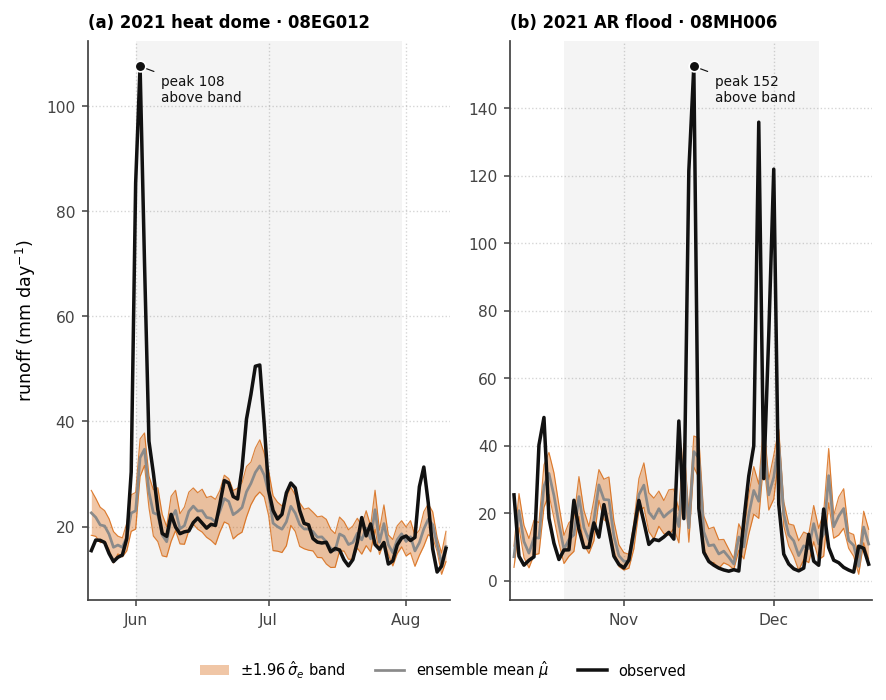

In [14]:
# figsize=(COL_W, 2.9)
fig, axes = plt.subplots(1, 2)
for k,(ax,(nm,(a,b))) in enumerate(zip(axes, EVENTS.items())):
    a_ts, b_ts = pd.Timestamp(a), pd.Timestamp(b)
    w = (dates >= a_ts-pd.Timedelta(days=10)) & (dates <= b_ts+pd.Timedelta(days=10))
    wi = np.where(w)[0]; core = (dates>=a_ts)&(dates<=b_ts)
    j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    d = dates[wi]; o = y[wi,j]; m = mu[wi,j]; sE = sig_e[wi,j]
    ax.axvspan(a_ts, b_ts, color="#000000", alpha=.045, lw=0, zorder=0)      # event window
    ax.fill_between(d, m-Z*sE, m+Z*sE, color=PALETTE["ens"], alpha=.35, lw=0, zorder=2,
                    label=r"$\pm1.96\,\hat{\sigma}_e$ band")
    ax.plot(d, m+Z*sE, color=PALETTE["ens"], lw=.6, alpha=.75, zorder=2)
    ax.plot(d, m-Z*sE, color=PALETTE["ens"], lw=.6, alpha=.75, zorder=2)
    ax.plot(d, m, color=PALETTE["mu"], lw=1.4, zorder=3, label=f"ensemble mean {MU}")
    ax.plot(d, o, color=PALETTE["obs"], lw=1.8, zorder=4, label="observed")
    oc = np.where(core[wi], o, np.nan); kp = int(np.nanargmax(oc))
    ax.plot(d[kp], o[kp], "o", ms=5.5, mfc=PALETTE["obs"], mec="white", mew=.9, zorder=6)
    ax.annotate(f"peak {o[kp]:.0f}\nabove band", xy=(d[kp], o[kp]),
                xytext=(11, -4), textcoords="offset points", ha="left", va="top",
                fontsize=7, color=PALETTE["obs"],
                arrowprops=dict(arrowstyle="-", lw=.6, color=PALETTE["obs"]))
    panel(ax, "ab"[k], f"{nm} · {stations[j]}", fontsize=8.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.margins(x=.01)
axes[0].set_ylabel(r"runoff (mm day$^{-1}$)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(.5, -.04), fontsize=7.5)
fig.tight_layout(rect=(0, .03, 1, 1)); plt.show()

**How to read it · station selection.** Each panel shows the single basin with the **largest observed peak** inside that event window, chosen automatically across all 269 basins:

```
core = (dates >= a) & (dates <= b)                                  # the event window
j = nanargmax( nanmax( where(core & valid, y, nan), axis=0 ) )      # basin with the biggest event peak
```

That gives the heat dome → **08EG012** (108 mm day⁻¹) and the AR flood → **08MH006** (152 mm day⁻¹); the plotted window is padded ±10 days so the rise and recession are visible.

- The $\pm1.96\,\hat{\sigma}_e$ band is a **sliver on $\hat{\mu}$** and never reaches the observed peak — the between-member spread does not widen where the model most under-predicts.
- This is **selection on the outcome** (the observed peak), so Fig. 1 is an **illustration, not evidence**, and not representative — the population result in Fig. 2 is the evidence base. Selecting on the *physical event magnitude* (not on model error or on $\hat{\sigma}_e$ itself) keeps it one step removed from circular, but it remains an anecdote backed by the curve, never a proof.

## Figure 2 — Tail exceedance by flow regime *(population evidence)*
One-sided upper exceedance: the fraction of test observations above the ensemble-only 97.5% bound ($\hat{\mu}+1.96\,\hat{\sigma}_e$; nominal 2.5%), by within-basin flow percentile, across **all 269 basins** over the test period. The lowest-flow decile is essentially calibrated (2.1% vs 2.5% nominal) — an **asset**, and consistent with a shared-extrapolation mechanism — while exceedance escalates monotonically to ~39% (≈16× nominal) at the top decile. The ensemble band is **confidently wrong, and worst at the extremes**.

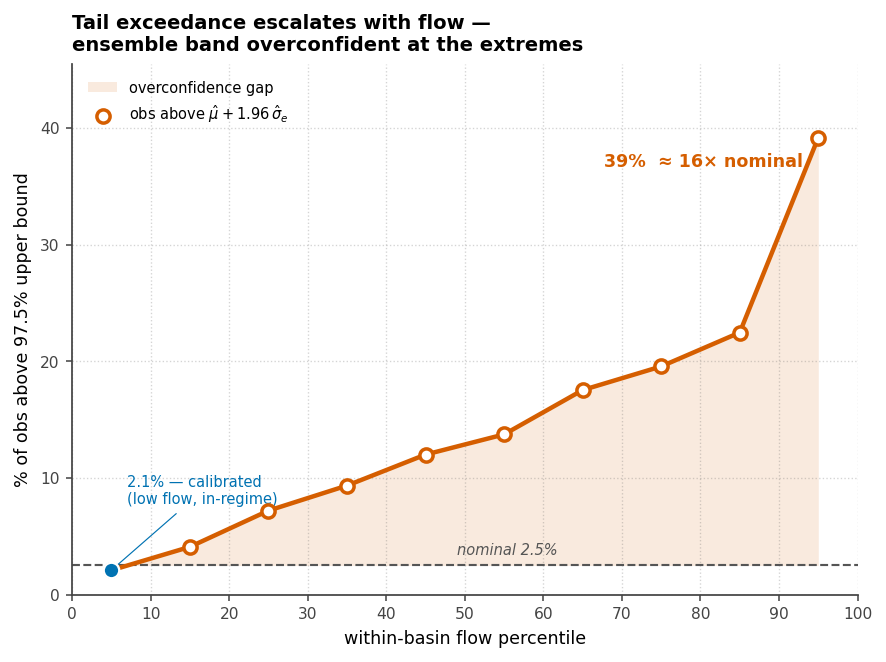

exceedance: low-flow decile 2.1% (nominal 2.5%)  |  top decile 39.2% (16x)
all 269 basins, test period; n per decile 68,359-101,657


In [15]:
up_e = y > (mu + Z*sig_e)                    # obs above ensemble-only 97.5% upper bound
ce, cc, nn = [], [], []
for k in range(10):
    sel = tb & (bi==k)
    if sel.sum()==0: continue
    ce.append(100*up_e[sel].mean()); cc.append((k+0.5)*10); nn.append(int(sel.sum()))
ce = np.array(ce); cc = np.array(cc); nom = 2.5

# figsize=(COL_W, 3.7)
fig, ax = plt.subplots()
ax.fill_between(cc, nom, ce, color=PALETTE["ens"], alpha=.13, lw=0, zorder=1,
                label="overconfidence gap")
ax.axhline(nom, ls="--", lw=1.1, color=PALETTE["ref"], zorder=2)
ax.plot(cc, ce, "-", color=PALETTE["ens"], lw=2.3, zorder=3)
ax.scatter(cc, ce, s=46, facecolor="white", edgecolor=PALETTE["ens"], linewidths=1.8, zorder=4,
           label=r"obs above $\hat{\mu}+1.96\,\hat{\sigma}_e$")
ax.scatter([cc[0]], [ce[0]], s=64, facecolor=PALETTE["indist"], edgecolor="white",
           linewidths=1.2, zorder=5)
ax.annotate(f"{ce[0]:.1f}% — calibrated\n(low flow, in-regime)", xy=(cc[0], ce[0]),
            xytext=(8, 34), textcoords="offset points", fontsize=7.5, color=PALETTE["indist"],
            arrowprops=dict(arrowstyle="-", lw=.6, color=PALETTE["indist"]))
ax.annotate(f"{ce[-1]:.0f}%  ≈ {ce[-1]/nom:.0f}× nominal", xy=(cc[-1], ce[-1]),
            xytext=(-8, -8), textcoords="offset points", ha="right", va="top",
            fontsize=9, fontweight="bold", color=PALETTE["ens"])
ax.text(49, nom+0.9, "nominal 2.5%", fontsize=7.5, color=PALETTE["ref"], style="italic")
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("% of obs above 97.5% upper bound")
ax.set_title("Tail exceedance escalates with flow —\nensemble band overconfident at the extremes",
             fontweight="bold", loc="left")
ax.set_xlim(0, 100); ax.set_ylim(0, max(ce)*1.16); ax.set_xticks(range(0, 101, 10))
ax.legend(loc="upper left", framealpha=.9, borderpad=.6)
fig.tight_layout(); plt.show()
print(f"exceedance: low-flow decile {ce[0]:.1f}% (nominal {nom}%)  |  top decile {ce[-1]:.1f}% ({ce[-1]/nom:.0f}x)")
print(f"all 269 basins, test period; n per decile {min(nn):,}-{max(nn):,}")

**How to read it.** Exceedance is the fraction of test observations above the ensemble-only upper bound $\hat{\mu}+1.96\,\hat{\sigma}_e$ (one-sided 97.5%). A calibrated band would sit at the **nominal 2.5%** (dashed) in every regime. Flows are first converted to **within-basin percentiles** (`rank(pct=True)` per station over valid days) and pooled across all 269 basins into deciles — so "high flow" means high *relative to each basin's own regime*, not just large rivers.

- **The low-flow decile is calibrated** (2.1% ≈ 2.5%) — an **asset**, not a caveat: the band is not uniformly broken.
- Exceedance then **escalates monotonically** to **≈ 39% (≈ 16× nominal)** at the top decile. The shaded region is the **overconfidence gap** — the excess above nominal — and it widens with flow.
- So the signal is **confidently wrong in a flow-dependent way, worst at the extremes.** The pattern points to a **common-mode** error in the high-flow *extrapolation* regime (outside the training range): all members miss the peak together, and a between-member spread — which can only see *disagreement among members* — is blind to error they share. $\hat{\sigma}^2_e$ is read as a lower bound on epistemic uncertainty, and that bound falls far short exactly where flows leave the trained regime.
- **This is the evidence base:** a population result over all 269 basins across the test period (≈ 68k–102k cells per decile), not an anecdote. Fig. 1's events are single-basin illustrations of this curve.

## Figure 3 — Informativeness under shift (confidently wrong, not decoupled)
**Left:** Spearman $\rho(\hat{\sigma}^2_e,\,|\text{error}|)$, in-distribution vs the 2021 OOD windows (bootstrap CI; anti-conservative under temporal autocorrelation). **Right:** sparsification on the OOD windows — removing the highest-$\hat{\sigma}^2_e$ cells first, vs an oracle (|error| order) and random. The ranking holds under shift and sparsification beats random ⇒ $\hat{\sigma}^2_e$ stays **informative**; only its *magnitude* undershoots. The signal misleads by being overconfident, not by decoupling from error.

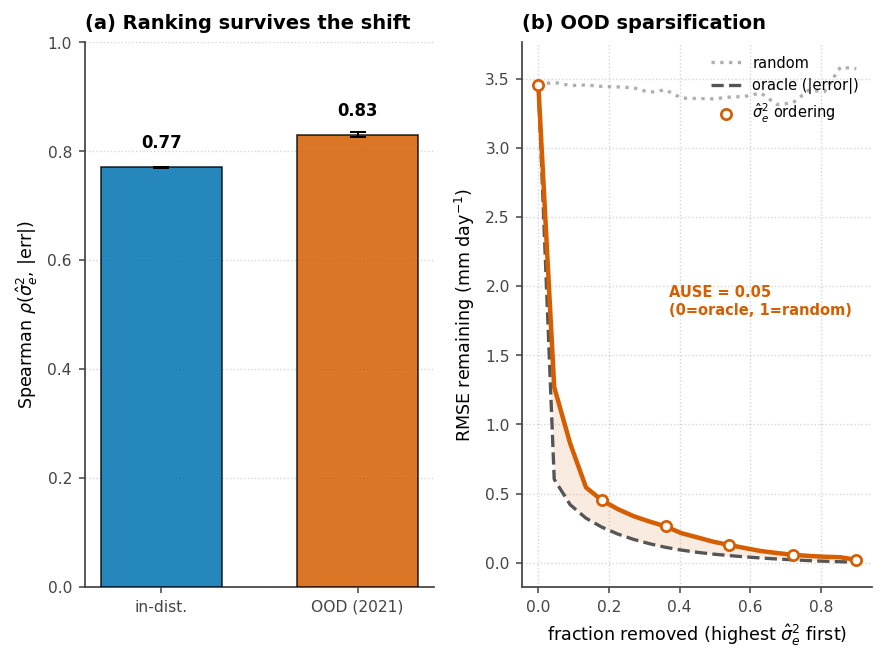

rho(sigma_e^2,|e|): in-dist +0.771 CI[+0.770,+0.772] | OOD +0.830 CI[+0.826,+0.835]
OOD normalized AUSE 0.05 (0=oracle, 1=random). Bootstrap CI anti-conservative under autocorrelation.


In [16]:
def boot_ci(x, z, B=400, seed=0):
    rng=np.random.default_rng(seed); n=len(x); out=np.empty(B)
    for b in range(B): ii=rng.integers(0,n,n); out[b]=spearmanr(x[ii],z[ii]).statistic
    return np.percentile(out,[2.5,97.5])
def sparsify(se, e2, nf=21, seed=0):
    n=len(e2); fr=np.linspace(0,0.9,nf); op=np.argsort(-se); oo=np.argsort(-e2); rng=np.random.default_rng(seed)
    curve=lambda order: np.array([np.sqrt(np.mean(e2[order[int(f*n):]])) for f in fr])
    cp,co_=curve(op),curve(oo); cr=np.mean([curve(rng.permutation(n)) for _ in range(10)],axis=0)
    num=np.trapezoid(cp-co_,fr); den=np.trapezoid(cr-co_,fr)
    return fr,cp,co_,cr,(num/den if den>0 else np.nan)

se_i,e_i = sigma_e2[M_ind], err[M_ind]
se_o,e_o,e2_o = sigma_e2[M_ood], err[M_ood], err2[M_ood]
r_i=spearmanr(se_i,e_i).statistic; ci_i=boot_ci(se_i,e_i)
r_o=spearmanr(se_o,e_o).statistic; ci_o=boot_ci(se_o,e_o)
fr,cp,co_,cr,an=sparsify(se_o,e2_o)

# figsize=(COL_W, 2.9)
fig, ax = plt.subplots(1, 2)
# (a) rank correlation survives the shift
ax[0].bar([0,1],[r_i,r_o],color=[PALETTE["indist"],PALETTE["ens"]],width=.62,
          edgecolor="black",linewidth=.8,alpha=.85,zorder=3)
ax[0].errorbar([0,1],[r_i,r_o],
    yerr=[[r_i-ci_i[0],r_o-ci_o[0]],[ci_i[1]-r_i,ci_o[1]-r_o]],
    fmt="none",ecolor="black",capsize=4,lw=1,zorder=4)
for x,v in zip([0,1],[r_i,r_o]): ax[0].text(x, v+0.035, f"{v:.2f}", ha="center", fontsize=8.5, fontweight="bold")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["in-dist.","OOD (2021)"])
ax[0].set_ylabel(r"Spearman $\rho(\hat{\sigma}^2_e,\,|\mathrm{err}|)$"); ax[0].set_ylim(0,1)
ax[0].grid(False); ax[0].grid(True, axis="y")
panel(ax[0], "a", "Ranking survives the shift")
# (b) OOD sparsification
ax[1].fill_between(fr,co_,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1)     # gap to oracle
ax[1].plot(fr,cr,":",color=PALETTE["random"],lw=1.7,label="random",zorder=2)
ax[1].plot(fr,co_,"--",color=PALETTE["ref"],lw=1.7,label="oracle (|error|)",zorder=3)
ax[1].plot(fr,cp,"-",color=PALETTE["ens"],lw=2.3,zorder=4)
ax[1].scatter(fr[::4],cp[::4],s=28,facecolor="white",edgecolor=PALETTE["ens"],
              linewidths=1.4,zorder=5,label=SIG+" ordering")
ax[1].set_xlabel("fraction removed (highest "+SIG+" first)")
ax[1].set_ylabel(r"RMSE remaining (mm day$^{-1}$)")
ax[1].legend(loc="upper right", framealpha=.9)
ax[1].annotate(f"AUSE = {an:.2f}\n(0=oracle, 1=random)", xy=(.42,.5), xycoords="axes fraction",
               fontsize=7.5, color=PALETTE["ens"], fontweight="bold")
panel(ax[1], "b", "OOD sparsification")
fig.tight_layout(); plt.show()
print(f"rho(sigma_e^2,|e|): in-dist {r_i:+.3f} CI[{ci_i[0]:+.3f},{ci_i[1]:+.3f}] | OOD {r_o:+.3f} CI[{ci_o[0]:+.3f},{ci_o[1]:+.3f}]")
print(f"OOD normalized AUSE {an:.2f} (0=oracle, 1=random). Bootstrap CI anti-conservative under autocorrelation.")

**How to read it.** Figs. 1–2 show the band is *too narrow*; Fig. 3 asks whether, under shift, the spread is still **informative** about where error is large — separating **confidently wrong** (orders error correctly, magnitude too small) from merely **decoupled** (spread unrelated to error). Ordering and magnitude are orthogonal: a signal can rank error perfectly yet be uniformly too small, and so overconfident everywhere.

**Left — ranking survives the shift.** Spearman $\rho(\hat{\sigma}^2_e,\,|\text{error}|)$, a *rank* correlation (magnitude-insensitive by construction), over in-distribution test cells vs the 2021 OOD windows. **0.77 → 0.83**: the ordering not only holds under shift, it slightly strengthens. The bootstrap 95% CIs are razor-thin only because $n$ is huge; they are **anti-conservative under temporal autocorrelation** (effective $n \ll$ cell count), so they are reported but not leaned on.

**Right — OOD sparsification.** Remove the highest-$\hat{\sigma}^2_e$ OOD cells first and track the RMSE of the remainder (vermillion), against an **oracle** (remove by true squared error — best case, grey dashed) and **random** (grey dotted). Normalized AUSE $=$ area(curve $-$ oracle) $/$ area(random $-$ oracle), so **0 = oracle, 1 = random**. **AUSE = 0.05** — using the spread to triage OOD error is near-optimal.

**Takeaway.** The spread stays **informative** under shift (near-oracle triage, ranking intact); only its **magnitude** undershoots. That is why the Fig. 1–2 failure is *confidently wrong* rather than broken — and it forecloses the reading that the spread is just noise under shift.